In [1]:
#pakage
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#create
X=np.array(
    [
        [0,0],
        [0,1],
        [1,0],
        [1,1]
    ]
)

In [3]:
Y_and=np.array([[0],[0],[0],[1]])
Y_or=np.array([[0],[1],[1],[1]])

In [4]:
def step(x):
    return np.where(x>=0,1,0)

In [5]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [6]:
def tanh(x):
    return np.tanh(x)

In [7]:
def relu(x):
    return np.maximum(0,x)

In [8]:
def leaky_relu(x):
    return np.where(x>0,x,x*0.01)

In [9]:
class SingleLayerNN:
    def __init__(self, activation, lr=0.1,epoch=1000):
        self.activation = activation
        self.lr = lr
        self.epoch = epoch
        self.loss = []

    def fit(self, X, y):
        self.W=np.random.randn(X.shape[1],1)*0.01
        self.b=np.zeros((1,))

        for _ in range(self.epoch):
          z=np.dot(X,self.W)+self.b
          y_hat=self.activation(z)

          loss=np.mean((y_hat-y)**2)
          self.loss.append(loss)

          error=y-y_hat
          self.W+=self.lr*np.dot(X.T,error)
          self.b+=self.lr*np.sum(error)

    def predict(self, X):
        z=np.dot(X,self.W)+self.b
        return self.activation(z)

In [10]:
def classify(y_hat, threshold=0.5):
    return (y_hat > threshold).astype(int)

In [11]:
activations={
    "step":step,
    "sigmoid":sigmoid,
    "tanh":tanh,
    "relu":relu,
    "leaky_relu":leaky_relu
}

In [12]:
print("AND Gate Results:")
for name,act in activations.items():
    model=SingleLayerNN(act)
    model.fit(X,Y_and)
    pred=model.predict(X)
    print(name,pred.T)

AND Gate Results:
step [[0 0 0 1]]
sigmoid [[1.96475272e-04 4.90467488e-02 4.90467282e-02 9.31207989e-01]]
tanh [[-0.28839189  0.28839189  0.28839189  0.71160811]]
relu [[0.00000000e+00 1.05260920e-08 1.05260920e-08 9.99999985e-01]]
leaky_relu [[-0.00970874  0.00970874  0.00970874  0.99029125]]


In [13]:
print("OR Gate Results:")
for name,act in activations.items():
    model=SingleLayerNN(act)
    model.fit(X,Y_or)
    pred=model.predict(X)
    print(name,pred.T)

OR Gate Results:
step [[0 1 1 1]]
sigmoid [[0.0515404  0.97947585 0.9794757  0.99997614]]
tanh [[0.01080556 0.99466085 0.99466244 0.99998536]]
relu [[0.25 0.75 0.75 1.25]]
leaky_relu [[0.25 0.75 0.75 1.25]]


In [14]:
model=SingleLayerNN(sigmoid)
model.fit(X,Y_and)

raw_output=model.predict(X)
binary_output=classify(raw_output)

print("Raw Output:\n",raw_output.T)
print("Binary Output:\n",binary_output.T)
print("True labels:\n",Y_and.T)

accuracy = np.mean(binary_output == Y_and)
print("Accuracy:", accuracy)


Raw Output:
 [[1.96485558e-04 4.90475354e-02 4.90475565e-02 9.31206853e-01]]
Binary Output:
 [[0 0 0 1]]
True labels:
 [[0 0 0 1]]
Accuracy: 1.0


In [15]:
model=SingleLayerNN(sigmoid)
model.fit(X,Y_or)

raw_output=model.predict(X)
binary_output=classify(raw_output)

print("Raw Output:\n",raw_output.T)
print("Binary Output:\n",binary_output.T)
print("True labels:\n",Y_or.T)

accuracy = np.mean(binary_output == Y_or)
print("Accuracy:", accuracy)

Raw Output:
 [[0.05153532 0.97947764 0.97947794 0.99997615]]
Binary Output:
 [[0 1 1 1]]
True labels:
 [[0 1 1 1]]
Accuracy: 1.0


In [16]:
model=SingleLayerNN(relu)
model.fit(X,Y_and)

raw_output=model.predict(X)
binary_output=classify(raw_output)

print("Raw Output:\n",raw_output.T)
print("Binary Output:\n",binary_output.T)
print("True labels:\n",Y_and.T)

accuracy = np.mean(binary_output == Y_and)
print("Accuracy:", accuracy)


Raw Output:
 [[0.00000000e+00 1.05081812e-08 1.05081812e-08 9.99999985e-01]]
Binary Output:
 [[0 0 0 1]]
True labels:
 [[0 0 0 1]]
Accuracy: 1.0


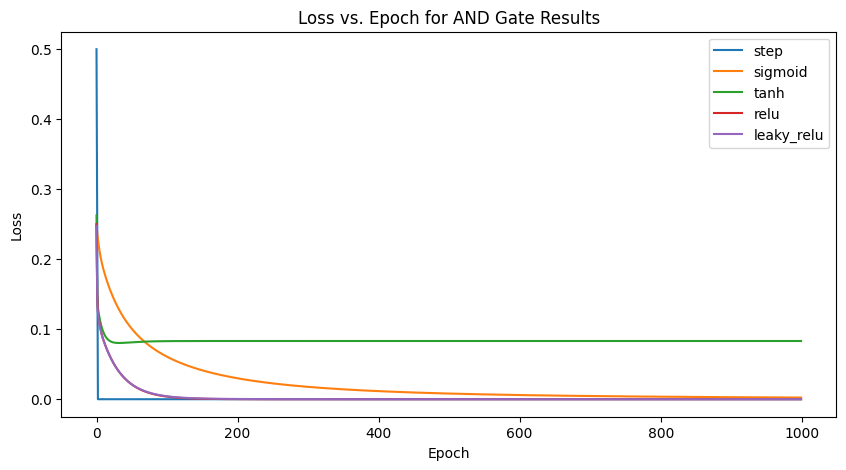

In [17]:
plt.figure(figsize=(10,5))

for name,act in activations.items():
    model=SingleLayerNN(act)
    model.fit(X,Y_and)
    plt.plot(model.loss,label=name)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs. Epoch for AND Gate Results")
plt.legend()
plt.legend()
plt.show()

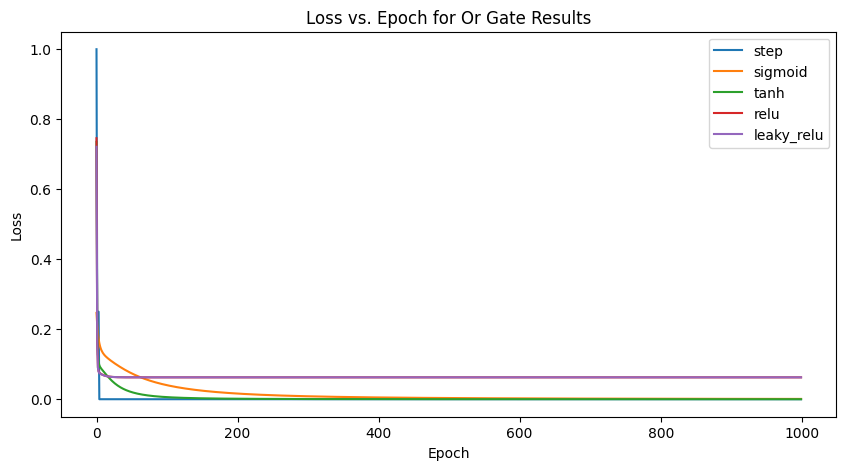

In [18]:
plt.figure(figsize=(10,5))

for name,act in activations.items():
    model=SingleLayerNN(act)
    model.fit(X,Y_or)
    plt.plot(model.loss,label=name)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs. Epoch for Or Gate Results")
plt.legend()
plt.show()
